# 🏦 Bank Marketing - Exploratory Data Analysis (EDA)

This notebook contains a full exploratory data analysis of the
Bank Marketing Dataset from UCI Machine Learning Repository.

**Dataset:** Bank Marketing (bank-full.csv)
**Records:** 45,211
**Features:** 16 + 1 Target
**Goal:** Predict if a client will subscribe to a term deposit (y = yes/no)

#Install & Import Libraries

In [5]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn -q

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📂 Step 1: Load Dataset

Loading the bank-full.csv dataset and displaying the first few rows
to understand the structure of the data.

In [6]:
# Load dataset
df = pd.read_csv('bank-full.csv')

# Display first 5 rows
print("Shape:", df.shape)
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 📊 Step 2: Dataset Overview

Checking basic information about the dataset including:
- Number of rows and columns
- Data types of each column
- Missing values

In [7]:
# Basic info
print("=" * 50)
print("📊 Dataset Shape:", df.shape)
print("=" * 50)

# Data types
print("\n📋 Data Types:")
print(df.dtypes)

# Missing values
print("\n❓ Missing Values:")
print(df.isnull().sum())

# Duplicates
print("\n🔁 Duplicate Rows:", df.duplicated().sum())

📊 Dataset Shape: (45211, 17)

📋 Data Types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

❓ Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

🔁 Duplicate Rows: 0


## 📈 Step 3: Statistical Summary

Displaying statistical summary for all numerical features
including mean, std, min, max, and quartiles.

In [8]:
# Statistical summary
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## 🎯 Step 4: Target Variable Distribution (y)

Analyzing the distribution of the target variable (y).
This helps us understand if the dataset is balanced or imbalanced.

Target Distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Percentage:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


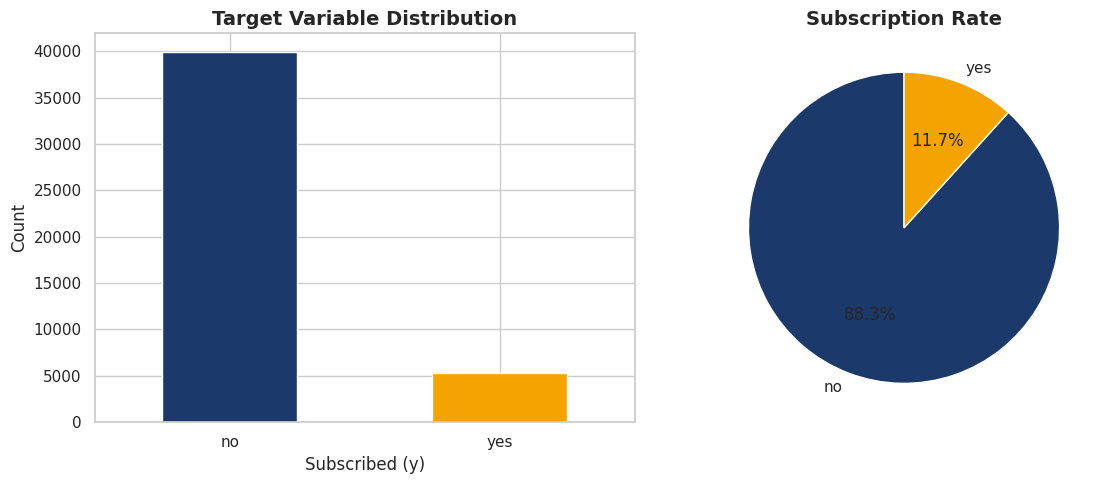

In [9]:
colors = ['#1B3A6B', '#F4A300']

# Count
print("Target Distribution:")
print(df['y'].value_counts())
print("\nPercentage:")
print(df['y'].value_counts(normalize=True) * 100)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
df['y'].value_counts().plot(kind='bar', ax=axes[0],
    color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Pie chart
df['y'].value_counts().plot(kind='pie', ax=axes[1],
    colors=colors, autopct='%1.1f%%',
    startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Subscription Rate', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 👤 Step 5: Client Demographics Analysis

Analyzing demographic features:
- Age distribution
- Job types vs subscription
- Marital status vs subscription
- Education level vs subscription

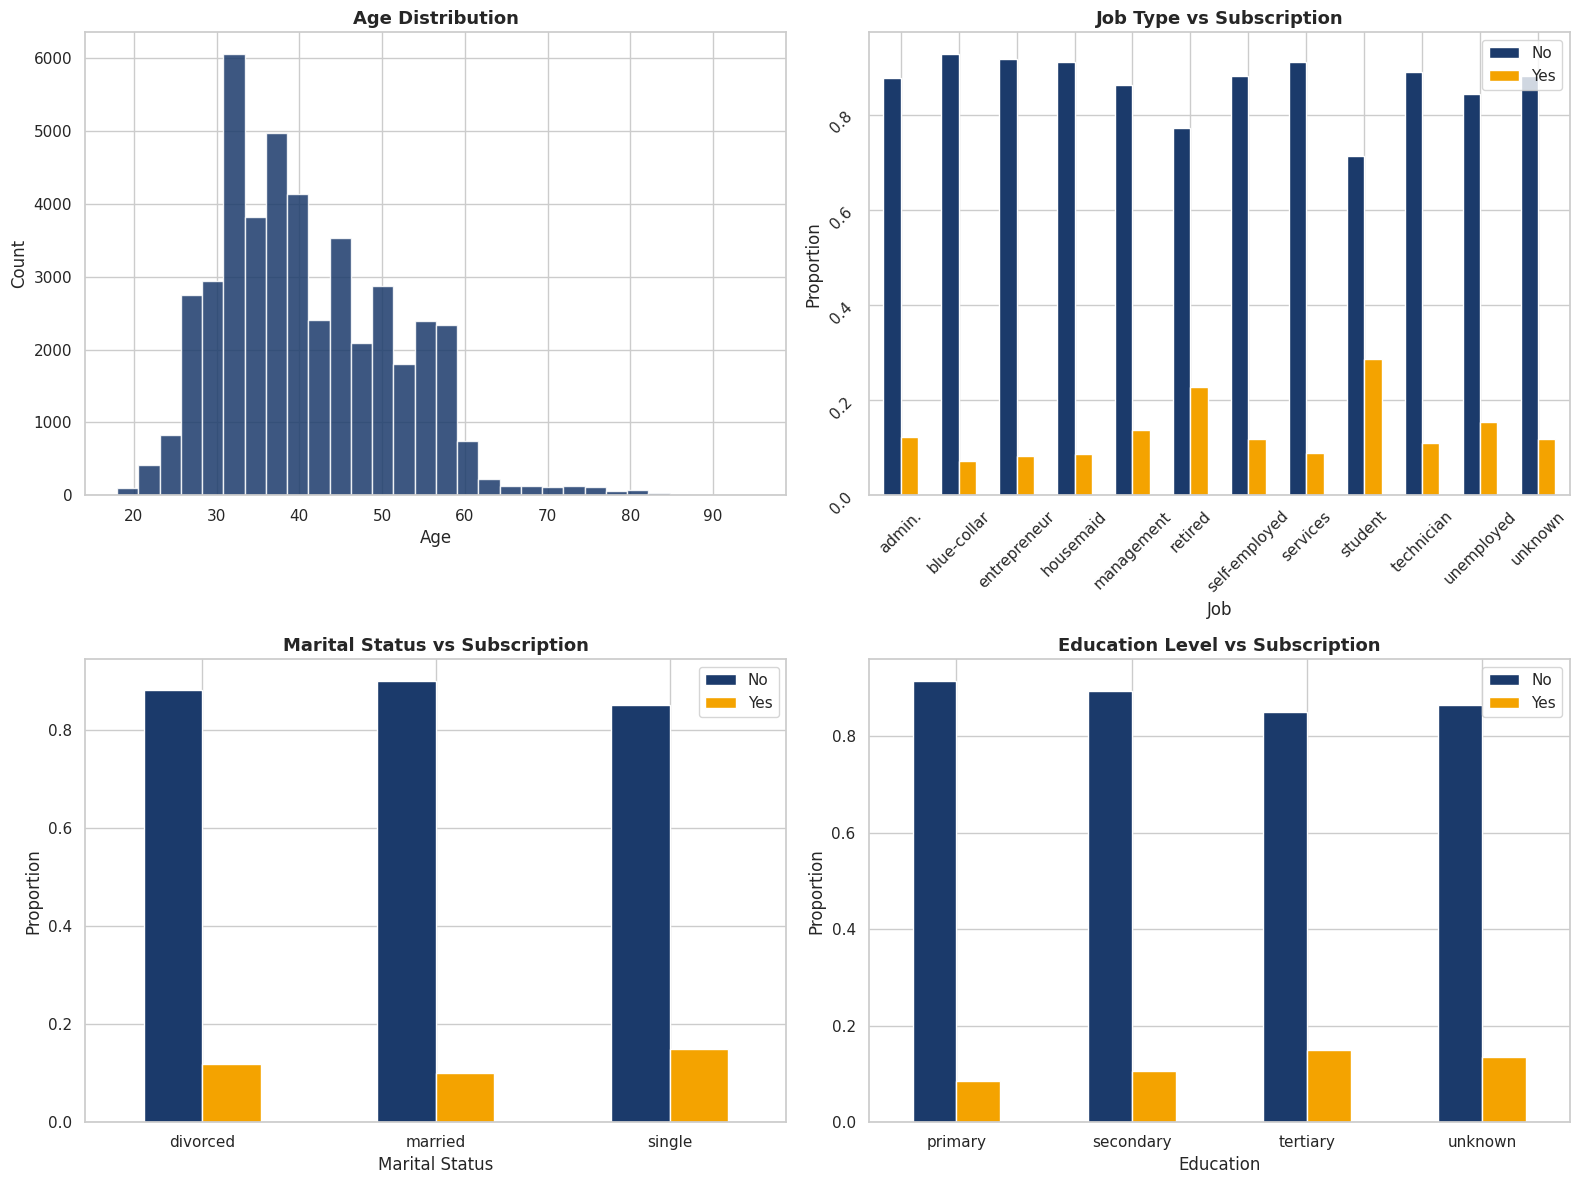

In [10]:
colors_main = '#1B3A6B'
colors_two = ['#1B3A6B', '#F4A300']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Age Distribution
axes[0,0].hist(df['age'], bins=30, color=colors_main,
               edgecolor='white', alpha=0.85)
axes[0,0].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')

# 2. Job vs Subscription
job_sub = df.groupby('job')['y'].value_counts(normalize=True).unstack()
job_sub.plot(kind='bar', ax=axes[0,1], color=colors_two,
             edgecolor='white', width=0.6)
axes[0,1].set_title('Job Type vs Subscription', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Job')
axes[0,1].set_ylabel('Proportion')
axes[0,1].tick_params(rotation=45)
axes[0,1].legend(['No', 'Yes'])

# 3. Marital Status vs Subscription
marital_sub = df.groupby('marital')['y'].value_counts(normalize=True).unstack()
marital_sub.plot(kind='bar', ax=axes[1,0], color=colors_two,
                 edgecolor='white', width=0.5)
axes[1,0].set_title('Marital Status vs Subscription', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Marital Status')
axes[1,0].set_ylabel('Proportion')
axes[1,0].tick_params(rotation=0)
axes[1,0].legend(['No', 'Yes'])

# 4. Education vs Subscription
edu_sub = df.groupby('education')['y'].value_counts(normalize=True).unstack()
edu_sub.plot(kind='bar', ax=axes[1,1], color=colors_two,
             edgecolor='white', width=0.5)
axes[1,1].set_title('Education Level vs Subscription', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Education')
axes[1,1].set_ylabel('Proportion')
axes[1,1].tick_params(rotation=0)
axes[1,1].legend(['No', 'Yes'])

plt.tight_layout()
plt.savefig('demographics.png', dpi=150, bbox_inches='tight')
plt.show()

## 💰 Step 6: Financial Features Analysis

Analyzing financial features:
- Balance distribution
- Housing loan vs subscription
- Personal loan vs subscription
- Credit default vs subscription

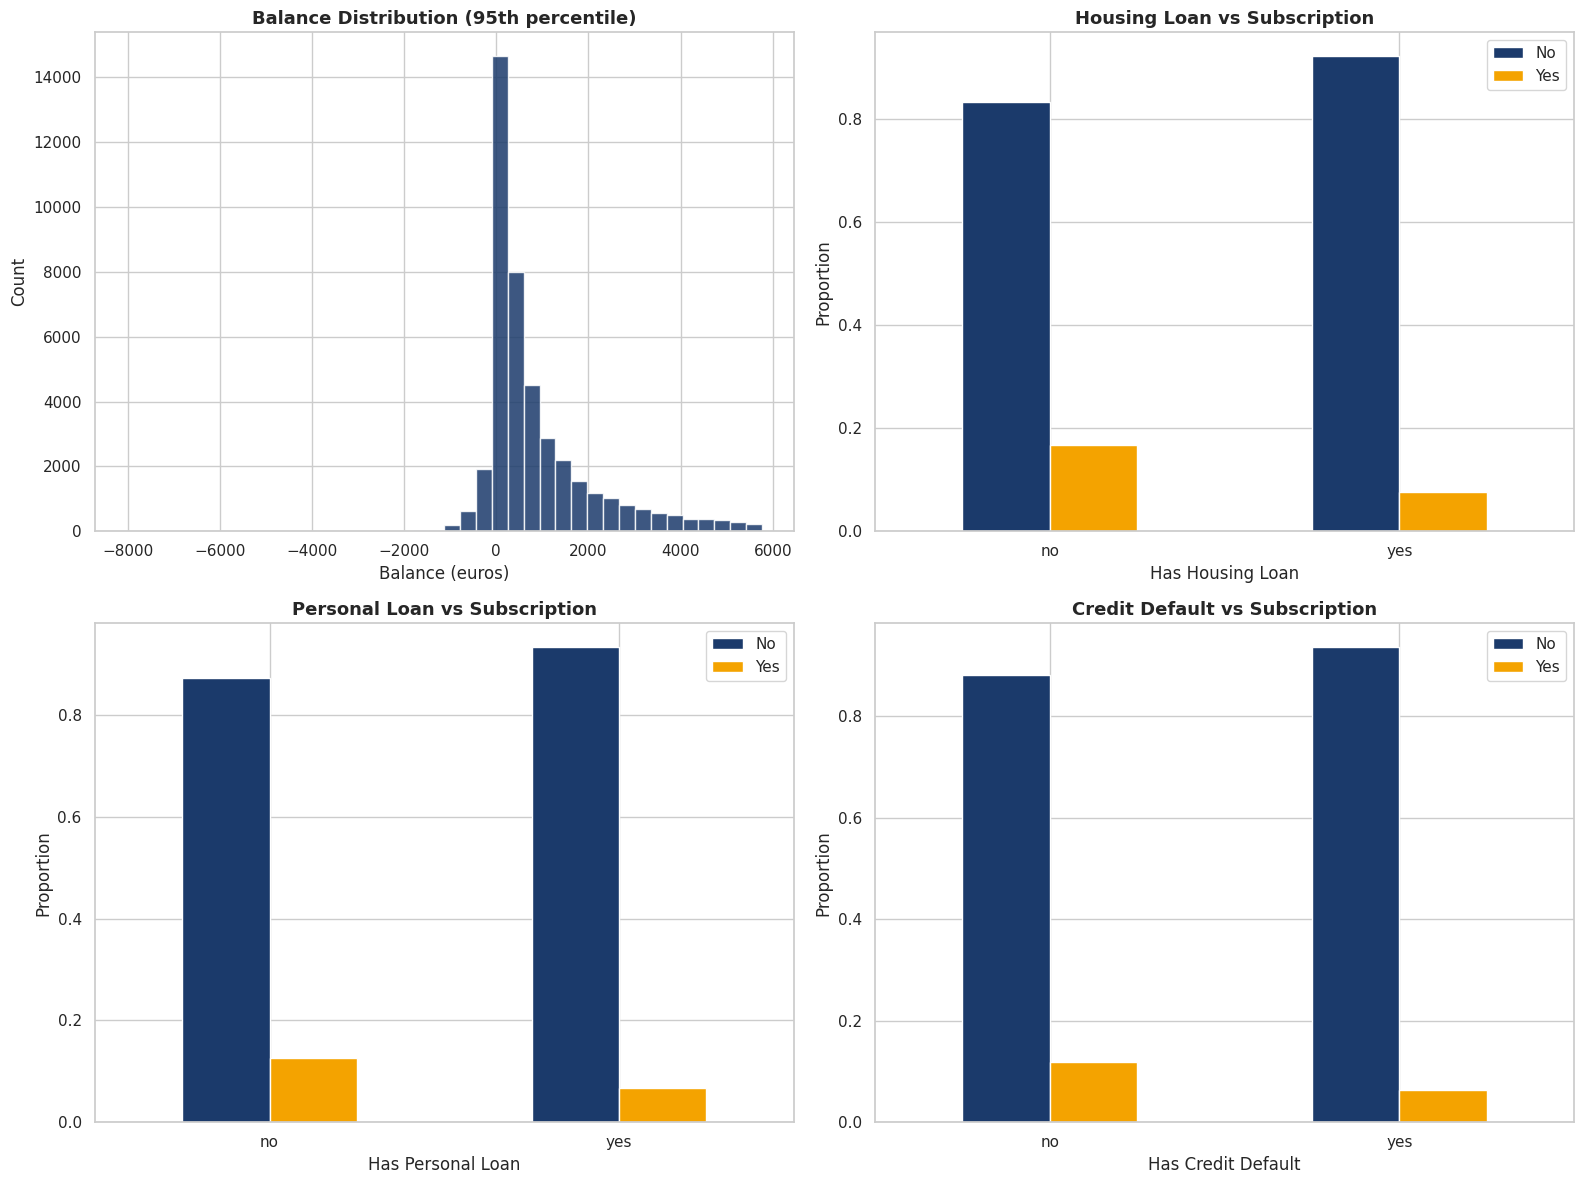

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Balance Distribution
axes[0,0].hist(df[df['balance'] < df['balance'].quantile(0.95)]['balance'],
               bins=40, color='#1B3A6B', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Balance Distribution (95th percentile)', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Balance (euros)')
axes[0,0].set_ylabel('Count')

# 2. Housing Loan vs Subscription
housing_sub = df.groupby('housing')['y'].value_counts(normalize=True).unstack()
housing_sub.plot(kind='bar', ax=axes[0,1], color=['#1B3A6B','#F4A300'],
                 edgecolor='white', width=0.5)
axes[0,1].set_title('Housing Loan vs Subscription', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Has Housing Loan')
axes[0,1].set_ylabel('Proportion')
axes[0,1].tick_params(rotation=0)
axes[0,1].legend(['No', 'Yes'])

# 3. Personal Loan vs Subscription
loan_sub = df.groupby('loan')['y'].value_counts(normalize=True).unstack()
loan_sub.plot(kind='bar', ax=axes[1,0], color=['#1B3A6B','#F4A300'],
              edgecolor='white', width=0.5)
axes[1,0].set_title('Personal Loan vs Subscription', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Has Personal Loan')
axes[1,0].set_ylabel('Proportion')
axes[1,0].tick_params(rotation=0)
axes[1,0].legend(['No', 'Yes'])

# 4. Default vs Subscription
default_sub = df.groupby('default')['y'].value_counts(normalize=True).unstack()
default_sub.plot(kind='bar', ax=axes[1,1], color=['#1B3A6B','#F4A300'],
                 edgecolor='white', width=0.5)
axes[1,1].set_title('Credit Default vs Subscription', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Has Credit Default')
axes[1,1].set_ylabel('Proportion')
axes[1,1].tick_params(rotation=0)
axes[1,1].legend(['No', 'Yes'])

plt.tight_layout()
plt.savefig('financial_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 📞 Step 7: Campaign Features Analysis

Analyzing campaign-related features:
- Call duration vs subscription
- Month of contact vs subscription
- Number of contacts vs subscription

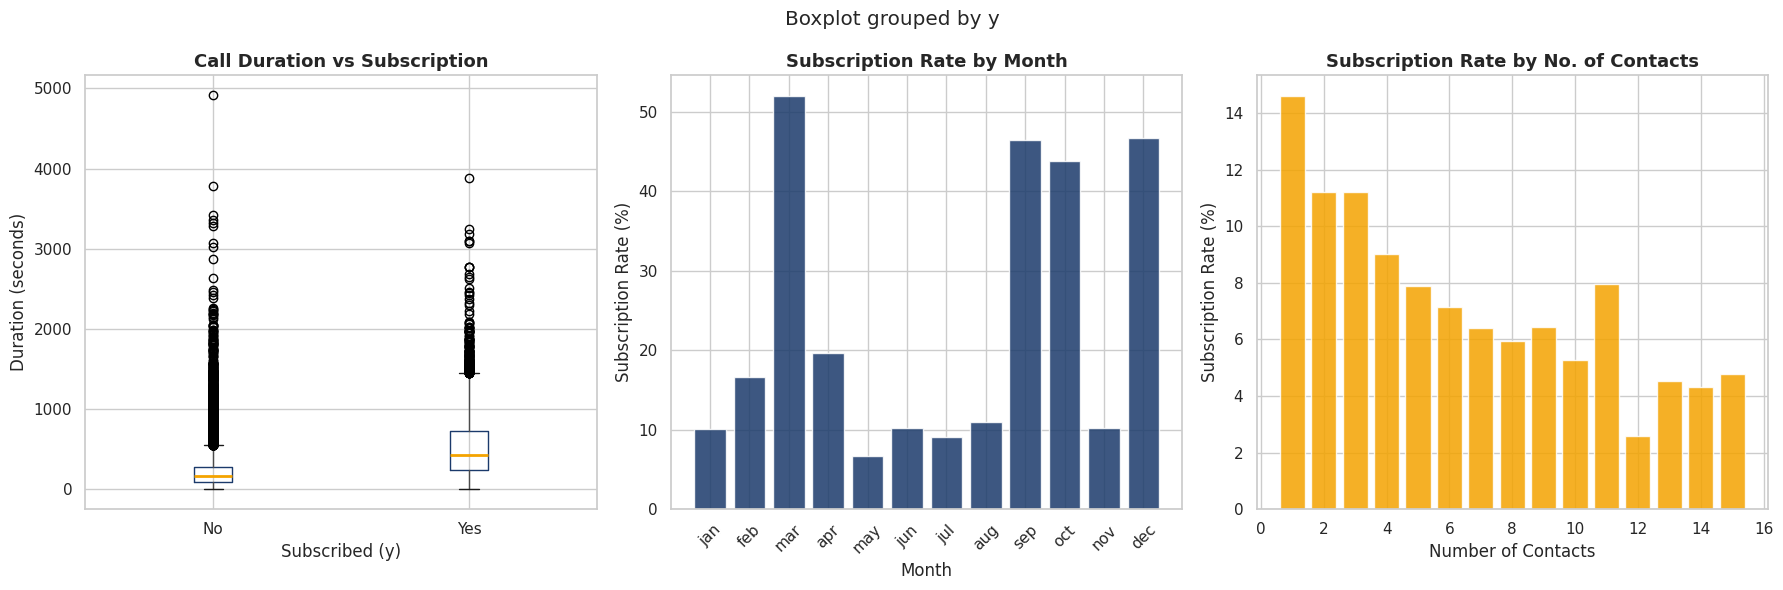

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Duration vs Subscription
df.boxplot(column='duration', by='y', ax=axes[0],
           boxprops=dict(color='#1B3A6B'),
           medianprops=dict(color='#F4A300', linewidth=2))
axes[0].set_title('Call Duration vs Subscription', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Duration (seconds)')
plt.sca(axes[0])
plt.xticks([1, 2], ['No', 'Yes'])

# 2. Month vs Subscription Rate
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']
month_sub = df.groupby('month')['y'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).reindex(month_order)
axes[1].bar(range(len(month_sub)), month_sub.values,
            color='#1B3A6B', edgecolor='white', alpha=0.85)
axes[1].set_title('Subscription Rate by Month', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].set_xticks(range(len(month_order)))
axes[1].set_xticklabels(month_order, rotation=45)

# 3. Campaign Contacts vs Subscription
campaign_sub = df.groupby('campaign')['y'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).head(15)
axes[2].bar(campaign_sub.index, campaign_sub.values,
            color='#F4A300', edgecolor='white', alpha=0.85)
axes[2].set_title('Subscription Rate by No. of Contacts', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Number of Contacts')
axes[2].set_ylabel('Subscription Rate (%)')

plt.tight_layout()
plt.savefig('campaign_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔥 Step 8: Correlation Heatmap

Analyzing the correlation between all numerical features
to identify relationships and multicollinearity.

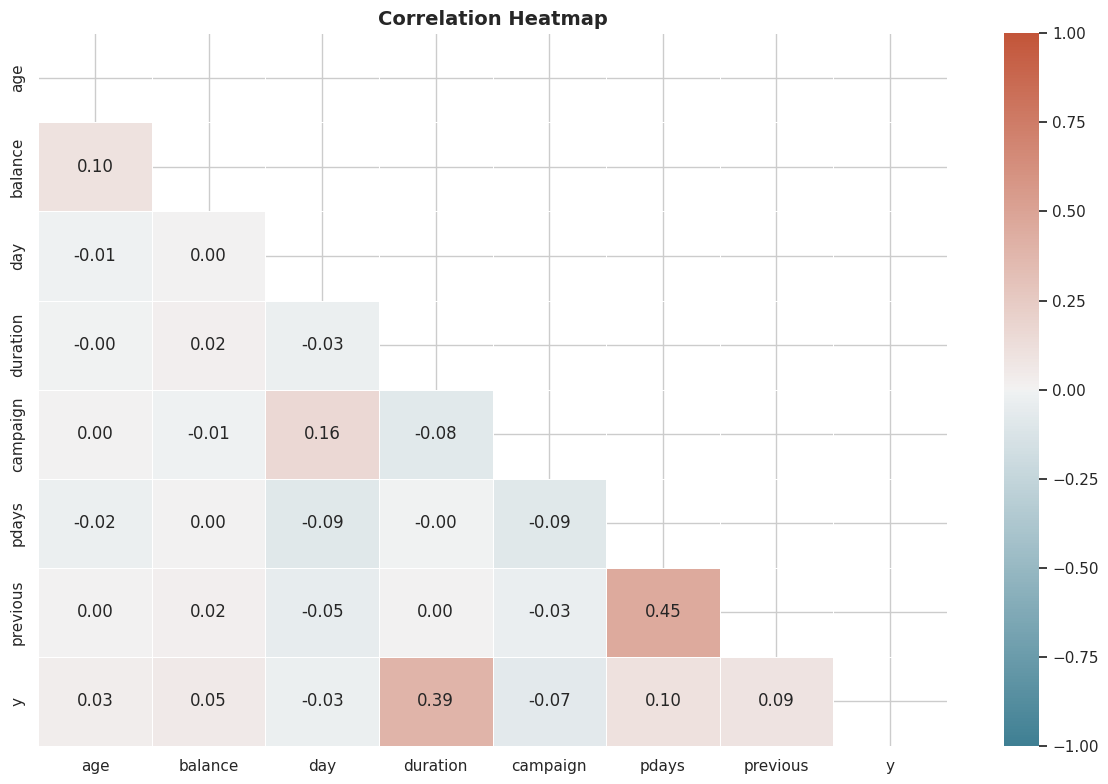

In [13]:
# Encode target for correlation
df_corr = df.copy()
df_corr['y'] = df_corr['y'].map({'yes': 1, 'no': 0})

# Select numerical columns
num_cols = df_corr.select_dtypes(include=np.number).columns

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(df_corr[num_cols].corr(), dtype=bool))
sns.heatmap(df_corr[num_cols].corr(),
            annot=True, fmt='.2f',
            cmap=sns.diverging_palette(220, 20, as_cmap=True),
            mask=mask,
            linewidths=0.5,
            vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 📝 Step 9: EDA Summary & Key Findings

Summarizing the most important insights discovered during EDA.

In [14]:
print("=" * 55)
print("📊 EDA SUMMARY - Bank Marketing Dataset")
print("=" * 55)

total = len(df)
yes = (df['y'] == 'yes').sum()
no  = (df['y'] == 'no').sum()

print(f"\n🎯 Target Variable:")
print(f"   Total Records  : {total:,}")
print(f"   Subscribed     : {yes:,}  ({yes/total*100:.1f}%)")
print(f"   Not Subscribed : {no:,} ({no/total*100:.1f}%)")

print(f"\n👤 Demographics:")
print(f"   Avg Age        : {df['age'].mean():.1f} years")
print(f"   Most Common Job: {df['job'].value_counts().index[0]}")

print(f"\n💰 Financial:")
print(f"   Avg Balance    : {df['balance'].mean():.1f} euros")
print(f"   Has Housing    : {(df['housing']=='yes').sum()/total*100:.1f}%")
print(f"   Has Loan       : {(df['loan']=='yes').sum()/total*100:.1f}%")

print(f"\n📞 Campaign:")
print(f"   Avg Duration   : {df['duration'].mean():.1f} seconds")
print(f"   Avg Contacts   : {df['campaign'].mean():.1f}")

print("\n" + "=" * 55)
print("✅ EDA Completed Successfully!")
print("=" * 55)

📊 EDA SUMMARY - Bank Marketing Dataset

🎯 Target Variable:
   Total Records  : 45,211
   Subscribed     : 5,289  (11.7%)
   Not Subscribed : 39,922 (88.3%)

👤 Demographics:
   Avg Age        : 40.9 years
   Most Common Job: blue-collar

💰 Financial:
   Avg Balance    : 1362.3 euros
   Has Housing    : 55.6%
   Has Loan       : 16.0%

📞 Campaign:
   Avg Duration   : 258.2 seconds
   Avg Contacts   : 2.8

✅ EDA Completed Successfully!
